<a href="https://colab.research.google.com/github/caglauzumcuu/Diabetes/blob/main/Diabetes_prediction_with_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Diabetes Prediction with KNN
---
In this project, the **K-Nearest Neighbors (KNN)** algorithm is used to predict diabetes.

**Dataset:** Pima Indians Diabetes Dataset  
**Target Variable:** `Outcome` (1 = Diabetic, 0 = Healthy)

### 📋 Workflow
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Modeling & Prediction
4. Model Evaluation
5. Hyperparameter Optimization
6. Final Model

## 📦 Libraries
Importing the necessary libraries.

In [18]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

## 1️⃣ Exploratory Data Analysis (EDA)
Loading the dataset and examining its general structure:
- `.head()` → First 5 rows
- `.shape` → Number of rows & columns
- `.describe()` → Statistical summary
- `value_counts()` → Target class distribution

In [19]:
df = pd.read_csv("diabetes.csv")

print("🔹 First 5 Rows:")
display(df.head())

print(f"\n🔹 Dataset Shape: {df.shape}")

print("\n🔹 Statistical Summary:")
display(df.describe().T)

print("\n🔹 Target Variable Distribution:")
print(df["Outcome"].value_counts())

🔹 First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



🔹 Dataset Shape: (768, 9)

🔹 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



🔹 Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


## 2️⃣ Data Preprocessing & Feature Engineering
- **Dependent / Independent variables** are separated.
- All features are brought to the **same scale** using `StandardScaler`.  
  *(Scaling is essential since KNN works based on distance!)*

In [20]:
y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)

X_scaled = StandardScaler().fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Scaling completed.")
display(X.head())

✅ Scaling completed.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


## 3️⃣ Modeling & Prediction
- A **KNN model** is built with default parameters (`n_neighbors=5`).
- A **prediction** is made for a randomly selected user.

In [21]:
knn_model = KNeighborsClassifier().fit(X, y)

random_user = X.sample(1, random_state=45)
prediction = knn_model.predict(random_user)

print(f"🔹 Random User:\n{random_user}")
print(f"\n🎯 Prediction: {'Diabetic' if prediction[0] == 1 else 'Healthy'}")

🔹 Random User:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  DiabetesPedigreeFunction       Age
195     0.342981  1.161295       0.770014       1.283638  1.130518  0.940144                 -0.232176 -0.360847

🎯 Prediction: Diabetic


## 4️⃣ Model Evaluation

### ⚠️ Train Error (Overfitting Check)
First, we check the model's performance on the **training data**.  
Then we measure the real performance with **5-Fold Cross Validation**.

| Metric | Description |
|--------|-------------|
| **Accuracy** | Overall correct prediction rate |
| **F1 Score** | Balance between Precision & Recall |
| **ROC-AUC** | Classification power (closer to 1 = better) |

In [22]:
# Prediction on training data (train error)
y_pred = knn_model.predict(X)
y_prob = knn_model.predict_proba(X)[:, 1]

print("📊 Training Data Performance:")
print(classification_report(y, y_pred))
print(f"AUC (Train): {roc_auc_score(y, y_prob):.4f}")

# 5-Fold Cross Validation
cv_results = cross_validate(knn_model, X, y, cv=5,
                            scoring=["accuracy", "f1", "roc_auc"])

print("\n📊 Cross Validation Results:")
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"  F1 Score : {cv_results['test_f1'].mean():.4f}")
print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f}")

📊 Training Data Performance:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       500
           1       0.79      0.70      0.74       268

    accuracy                           0.83       768
   macro avg       0.82      0.80      0.81       768
weighted avg       0.83      0.83      0.83       768

AUC (Train): 0.9018

📊 Cross Validation Results:
  Accuracy : 0.7331
  F1 Score : 0.5906
  ROC-AUC  : 0.7805


## 5️⃣ Hyperparameter Optimization
All K values **from 2 to 50** are tested using `GridSearchCV`.  
The best `n_neighbors` is found using 5-Fold Cross Validation.

In [23]:
knn_model = KNeighborsClassifier()

knn_params = {"n_neighbors": range(2, 50)}

knn_gs_best = GridSearchCV(knn_model,
                           knn_params,
                           cv=5,
                           n_jobs=-1,
                           verbose=1).fit(X, y)

print(f"✅ Best Parameters: {knn_gs_best.best_params_}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
✅ Best Parameters: {'n_neighbors': 17}


## 6️⃣ Final Model
The **final model** is built with the best `n_neighbors` parameter found.  
Performance is measured again with cross validation and compared with the baseline.

In [24]:
knn_final = knn_model.set_params(**knn_gs_best.best_params_).fit(X, y)

cv_results = cross_validate(knn_final, X, y, cv=5,
                            scoring=["accuracy", "f1", "roc_auc"])

print("🏆 Final Model - Cross Validation Results:")
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"  F1 Score : {cv_results['test_f1'].mean():.4f}")
print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f}")

# New user prediction
random_user = X.sample(1)
prediction = knn_final.predict(random_user)

print("\n Random User")
print(prediction)
print(f"\n🎯 Final Model Prediction: {'Diabetic' if prediction[0] == 1 else 'Healthy'}")

🏆 Final Model - Cross Validation Results:
  Accuracy : 0.7670
  F1 Score : 0.6171
  ROC-AUC  : 0.8128

 Random User
[0]

🎯 Final Model Prediction: Healthy


## 🔧 Improvements

### 1️⃣ Missing Value Treatment — Step 1: Replace 0s with NaN
The following columns contain `0` values that are biologically impossible.  
These are replaced with `NaN` first, before any further processing.

| Column | Reason |
|--------|--------|
| `Glucose` | Blood sugar cannot be 0 |
| `BloodPressure` | Blood pressure cannot be 0 |
| `SkinThickness` | Skin thickness cannot be 0 |
| `Insulin` | Insulin cannot be 0 |
| `BMI` | BMI cannot be 0 |

In [25]:
import numpy as np

# Columns where 0 is biologically impossible
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0s with NaN
df[zero_columns] = df[zero_columns].replace(0, np.nan)

print("🔹 Missing Values After Replacement:")
print(df.isnull().sum())

🔹 Missing Values After Replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 2️⃣ Outlier Analysis & Capping
Outliers are detected using the **IQR (Interquartile Range)** method.  
Values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are considered outliers and **capped (clipped)**.



In [26]:
def replace_with_thresholds(dataframe, variable):
    Q1 = dataframe[variable].quantile(0.25)
    Q3 = dataframe[variable].quantile(0.75)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    dataframe.loc[dataframe[variable] < low_limit, variable] = low_limit
    dataframe.loc[dataframe[variable] > up_limit, variable] = up_limit

def check_outlier(dataframe, variable):
    Q1 = dataframe[variable].quantile(0.25)
    Q3 = dataframe[variable].quantile(0.75)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    return dataframe[(dataframe[variable] < low_limit) | (dataframe[variable] > up_limit)].any(axis=None)

num_cols = [col for col in df.columns if col != "Outcome"]

print("🔹 Outlier Check Before Capping:")
for col in num_cols:
    print(f"  {col}: {check_outlier(df, col)}")

for col in num_cols:
    replace_with_thresholds(df, col)

print("\n🔹 Outlier Check After Capping:")
for col in num_cols:
    print(f"  {col}: {check_outlier(df, col)}")

🔹 Outlier Check Before Capping:
  Pregnancies: True
  Glucose: False
  BloodPressure: True
  SkinThickness: True
  Insulin: True
  BMI: True
  DiabetesPedigreeFunction: True
  Age: True

🔹 Outlier Check After Capping:
  Pregnancies: False
  Glucose: False
  BloodPressure: False
  SkinThickness: False
  Insulin: False
  BMI: False
  DiabetesPedigreeFunction: False
  Age: False


/tmp/ipykernel_23007/3163489800.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[variable] < low_limit, variable] = low_limit
/tmp/ipykernel_23007/3163489800.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[variable] < low_limit, variable] = low_limit


### 3️⃣ Missing Value Treatment — Step 2: Median Imputation
After outlier capping, `NaN` values are filled with the **median** of each column.

> ✅ Median is used instead of mean because it is more robust to outliers.

In [29]:
# Fill NaN values with median
df[zero_columns] = df[zero_columns].fillna(df[zero_columns].median())

print("✅ Missing values filled with median.")
print(df.isnull().sum())

✅ Missing values filled with median.
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 4️⃣ Feature Engineering
New features are created to capture additional information and improve model performance.

In [30]:
# BMI categories
df["BMI_Category"] = pd.cut(df["BMI"],
                             bins=[0, 18.5, 24.9, 29.9, 100],
                             labels=["Underweight", "Normal", "Overweight", "Obese"])

# Age categories
df["Age_Category"] = pd.cut(df["Age"],
                             bins=[0, 30, 45, 100],
                             labels=["Young", "Middle", "Senior"])

# Glucose * Insulin interaction
df["Glucose_Insulin"] = df["Glucose"] * df["Insulin"]

# BMI * Age interaction
df["BMI_Age"] = df["BMI"] * df["Age"]

# Encode categorical features
df = pd.get_dummies(df, columns=["BMI_Category", "Age_Category"], drop_first=True)

print("✅ New features created.")
print(f"New shape: {df.shape}")
display(df.head())

✅ New features created.
New shape: (768, 16)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Insulin,BMI_Age,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese,Age_Category_Middle,Age_Category_Senior
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1,18500.0,1680.0,False,False,True,False,True
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0,10625.0,824.6,False,True,False,True,False
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1,22875.0,745.6,True,False,False,True,False
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,8366.0,590.1,False,True,False,False,False
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,23016.0,1422.3,False,False,True,True,False


### 5️⃣ Handling Class Imbalance — SMOTE
The dataset is imbalanced: **500 Healthy vs 268 Diabetic**.  
**SMOTE (Synthetic Minority Oversampling Technique)** generates synthetic samples for the minority class to balance the dataset.

> ⚠️ SMOTE is applied **only on training data** to avoid data leakage.

In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)

# Split before SMOTE to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🔹 Before SMOTE:")
print(f"  Train — Healthy: {sum(y_train==0)}, Diabetic: {sum(y_train==1)}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\n✅ After SMOTE:")
print(f"  Train — Healthy: {sum(y_train==0)}, Diabetic: {sum(y_train==1)}")

🔹 Before SMOTE:
  Train — Healthy: 401, Diabetic: 213

✅ After SMOTE:
  Train — Healthy: 401, Diabetic: 401


### 6️⃣ Scaling
After SMOTE, all features are scaled using `StandardScaler`.

> ⚠️ Scaler is **fit on training data only** and applied to both train and test sets to avoid data leakage.

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Scaling completed.")
print(f"  Train shape: {X_train.shape}")
print(f"  Test shape: {X_test.shape}")

✅ Scaling completed.
  Train shape: (802, 15)
  Test shape: (154, 15)


### 7️⃣ Modeling & Hyperparameter Optimization
KNN model is built and optimized using **GridSearchCV** with 5-Fold Cross Validation.

In [33]:
knn_model = KNeighborsClassifier()

knn_params = {"n_neighbors": range(2, 50)}

knn_gs_best = GridSearchCV(knn_model,
                           knn_params,
                           cv=5,
                           n_jobs=-1,
                           verbose=1).fit(X_train, y_train)

print(f"✅ Best Parameters: {knn_gs_best.best_params_}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
✅ Best Parameters: {'n_neighbors': 8}


### 8️⃣ Final Model & Evaluation
The final model is built with the best `n_neighbors` parameter.  
Performance is evaluated on the **test set** and compared with the baseline model.

| | Baseline | Improved |
|---|---|---|
| Accuracy | 0.77 | ? |
| F1 Score | 0.62 | ? |
| ROC-AUC | 0.81 | ? |

In [34]:
knn_final = KNeighborsClassifier(**knn_gs_best.best_params_).fit(X_train, y_train)

y_pred = knn_final.predict(X_test)
y_prob = knn_final.predict_proba(X_test)[:, 1]

print("🏆 Final Model - Test Set Results:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

🏆 Final Model - Test Set Results:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

ROC-AUC: 0.7762


### 📊 Model Visualization
#### Confusion Matrix & ROC Curve
Visual evaluation of the final model's performance.

/tmp/ipykernel_23007/1894506965.py:20: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


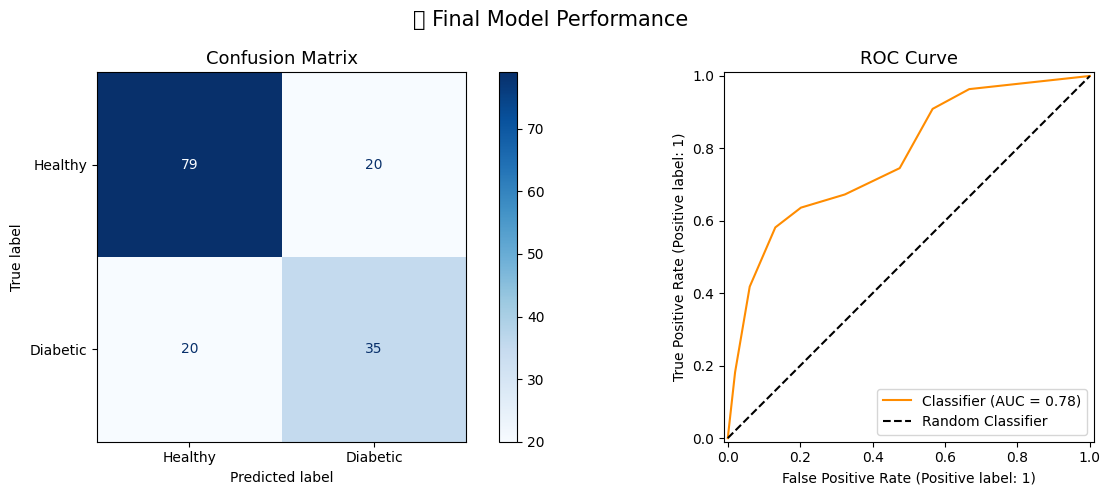

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                         display_labels=["Healthy", "Diabetic"],
                                         cmap="Blues",
                                         ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=13)

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color="darkorange")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].legend()

plt.suptitle("🏆 Final Model Performance", fontsize=15)
plt.tight_layout()
plt.show()